In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import time
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
#import csv
import os.path
from os import path
from numpy.matlib import repmat
%matplotlib inline
from preprocess import preprocessing as pre

from sklearn.decomposition import PCA


In [ ]:
testSounds = ["00f0204f_nohash_2", "00f0204f_nohash_0", "004ae714_nohash_0", "004ae714_nohash_1", "0132a06d_nohash_0", "0132a06d_nohash_2", "0132a06d_nohash_4", "0135f3f2_nohash_1", "0137b3f4_nohash_0", "0137b3f4_nohash_1"]              
trainingSounds = ["00f0204f_nohash_2"]
scale = 15 

trainingIndex = [4000,6000]
testingIndex = [4000, 3000, 8000, 7000, 6000, 5500, 8000, 6000, 4500, 7500]
range_f = 100
step_f = 10
cfN = 20 #channel frequency number
colors = ['y','k','b','y','k','b','y','k','b','y']

trainingAudio = pre.createTraining(trainingSounds, trainingIndex, cfN, range_f, step_f, scale)
testAudio = pre.createTesting(testSounds, cfN, testingIndex, colors, range_f, step_f, scale)

In [4]:
from lib import epl
nGammaPerTraining = 10
nGammaPerSound = 10  #for this dataset nGammaPerSound = 5 is not enough for differentiation as shown in SImatrix
print("Number of sounds to train = " + str(lenTraining)); 
print("Number of sounds to test = " + str(lenTest)); 

#Network initialization
nMCs = len(trainingAudio[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*lenTraining;     #every MC has 5 GCs per sound  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(sound, learn_flag=0, nGammaPerSound=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(sound); 
    for j in range(0, nGammaPerSound):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, lenTraining):
    print("Training sound " + str(i+1)) 
    sniff(trainingAudio[i], learn_flag=1,nGammaPerSound = nGammaPerTraining); 
    # changed nGammaPerSound from 5 to 10
    epl.GClayer.invokeNeurogenesis();
#added this for loop to change structure of epl.gammaCode
for i in range(0, lenTraining):
    sniff(trainingAudio[i], learn_flag=0, nGammaPerSound = nGammaPerSound); #try nGammaPerTraining
    
#Testing
for i in range(0, lenTest):
    sniff(testAudio[i], learn_flag=0, nGammaPerSound = nGammaPerSound); 
    if((i+1)%10==0):
        print(str(i+1) + " sounds tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")


Number of sounds to train = 2
Number of sounds to test = 10
Training sound 1
Training sound 2
10 sounds tested
Simulation Duration = 1846.5155522823334s


## epl gammaCode parsing

if I keep nGammaPerTraining in the second training loop, I need to change it in epl gammaCode parsing as well

In [5]:
#Remember the first training loop uses nGammaPerSound = 10

gammaCode_size = lenTraining*(nGammaPerTraining + nGammaPerTraining) + lenTest * nGammaPerSound
(gammaCode_size,len(epl.gammaCode))

(140, 140)

In [6]:
trained = np.array(epl.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerSound)]).reshape(nGammaPerSound, lenTraining,-1)#/nGammaPerSound, -1)
#put lenTest/nGammaPerSound into another variable
tested = np.array(epl.gammaCode[lenTraining*(nGammaPerTraining+nGammaPerSound):]).reshape(nGammaPerSound, lenTest, -1)

In [7]:

true_negative = 0
false_positive = 0


SImatrix = np.zeros((lenTraining, lenTest), dtype =float)  
for i in range(0, len(trained[-1])):
    for j in range(0, len(tested[-1])):
        SImatrix[i][j] = (pre.computeSimilarity(trained[-1][i], tested[-1][j]))
decisionMatrix = (SImatrix> 0.75)

In [8]:
#designing truth Table
truthTable = np.tile([True, False], (lenTest,1)).T

In [9]:
truthTable

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [False, False, False, False, False, False, False, False, False,
        False]])

In [10]:
decisionMatrix

array([[False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False]])

In [11]:
SImatrix

array([[0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917,
        0.0917, 0.0917],
       [0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917,
        0.0917, 0.0917]])

In [12]:
for l in (decisionMatrix==truthTable):
    true_negative += sum((decisionMatrix==truthTable).reshape((1,20)))

In [13]:
sum((decisionMatrix==truthTable).reshape((1,20)))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [14]:
decisionMatrix==truthTable

array([[False, False, False, False, False, False, False, False, False,
        False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])

In [15]:
pre.results(decisionMatrix, truthTable)

(10, 10)

Text(0.5, 0, 'Time (index)')

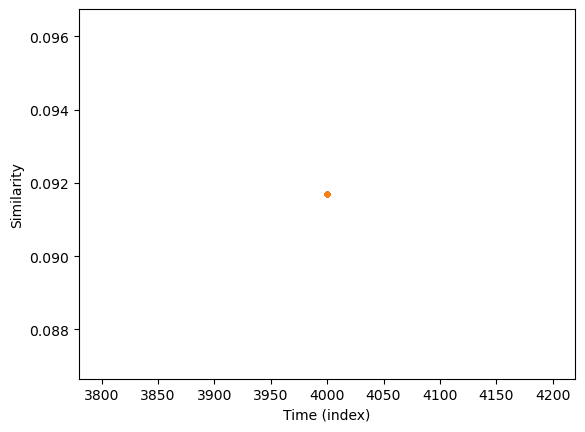

In [16]:
plt.plot([trainingIndex[0]]*lenTest , SImatrix.T, ".") 
plt.ylabel('Similarity')
plt.xlabel('Time (index)')


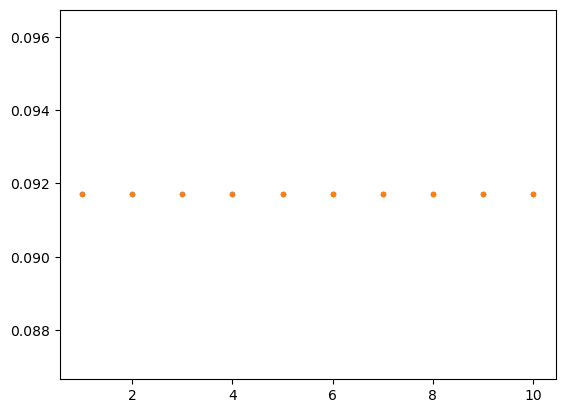

In [17]:
plt.plot(range(1,11), SImatrix.T, ".") 


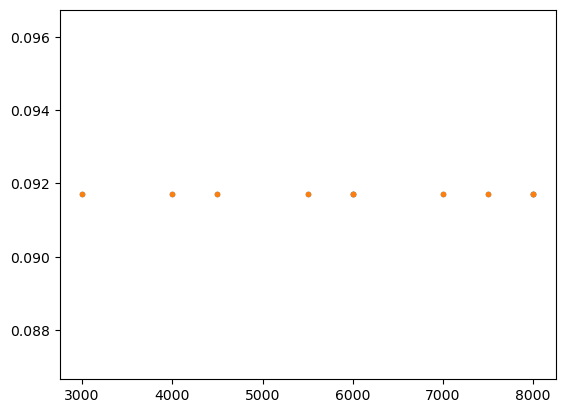

In [18]:
plt.plot(testingIndex, SImatrix.T, ".") 